In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

df = pd.read_csv('civic_issue_dataset.csv')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))
print('Logistic Regression accuracy:', lr_acc)

Logistic Regression accuracy: 0.77


In [94]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
print("Decision Tree",dt_acc)

Decision Tree 0.58


In [95]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=800, random_state=42)
rf.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))
print("Random Forest Accuracy",rf_acc)

Random Forest Accuracy 0.63


In [96]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler2 = StandardScaler()
X_all_sc = scaler2.fit_transform(X)

n_clusters = y.nunique()
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_all_sc)

label_map = {}
for cluster_id in range(n_clusters):
    mask = cluster_labels == cluster_id
    majority = y.values[mask]
    label_map[cluster_id] = pd.Series(majority).value_counts().idxmax()

y_pred_km = np.array([label_map[c] for c in cluster_labels])
km_acc = accuracy_score(y.values, y_pred_km)
print("K-Means Accuracy",km_acc)

K-Means Accuracy 0.398


In [97]:
import matplotlib.pyplot as plt
import numpy as np

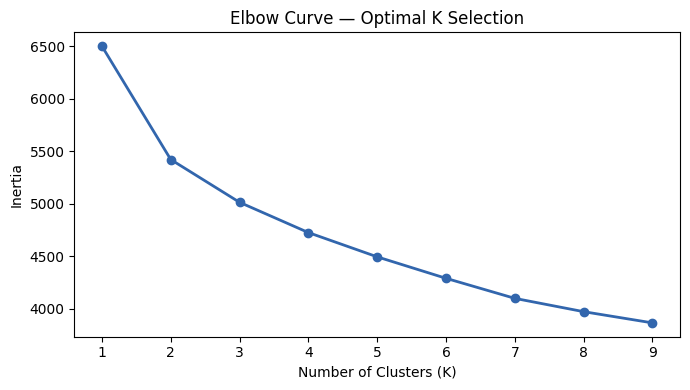

In [98]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 10)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_all_sc)
    inertia.append(km_temp.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker='o', color='#3266ad', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve — Optimal K Selection')
plt.xticks(k_range)
plt.tight_layout()
plt.show()